In [1]:
from selenium import webdriver
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.support import expected_conditions
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.support.ui import Select

import pandas as pd
import pickle
import os
import sys
import warnings
import time

from bs4 import BeautifulSoup
import requests
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36", "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8", "Accept-Language": "en-US,en;q=0.9", "Referer": "https://www.ewg.org/tapwater/", "Connection": "keep-alive"}



from selenium.webdriver.edge.options import Options

edge_options = Options()
#edge_options.add_argument('--headless')
edge_options.add_argument("--disable-images")  # Disable images
edge_options.add_argument("--disable-javascript")  # Disable JavaScript
edge_options.add_argument("--disable-plugins")  # Disable plugins
edge_options.add_argument("--disable-extensions")  # Disable extensions
edge_options.add_argument("--blink-settings=imagesEnabled=false")  # Another image disabling flag


# Set a minimal User-Agent (like a text-only browser)
edge_options.add_argument("user-agent=Links (2.25; Linux 2.4.24)")

driver = webdriver.Edge(options=edge_options)
#driver.execute_cdp_cmd("Network.setBlockedURLs", {"urls": ["*.jpg", "*.png", "*.gif","*.svg"]})
#driver.execute_cdp_cmd("Network.enable", {})


driver.maximize_window()

driver.execute_script("document.body.style.zoom='67%'")

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


plt.style.use('ggplot')

In [2]:
url="https://www.oxfordeconomics.com/global-cities-index/"

driver.get(url)
time.sleep(2)
driver.execute_script("window.scrollBy(0, 1500);")
time.sleep(2)

In [3]:
all_data=[]

list_sel='div[aria-label="All cities in the index, ranked"] button[type="button"]'
country_elements=driver.find_elements(By.CSS_SELECTOR, list_sel)

i=0
while i < len(country_elements):
    country_element=country_elements[i]

    parts=country_element.text.split('\n')
    rank=parts[0]
    city=parts[1]
    country=parts[2]

    country_element.click()
    time.sleep(1)

    info_element=driver.find_elements(By.CSS_SELECTOR, 'div[class="oe-block-gci-globe__info-body"] div[class="oe-block-gci-globe__info-row"]')
    data={e.text.split('\n')[0]:e.text.split('#')[1].split('·')[0] for e in info_element}

    data_dict={'Rank':rank, 'City':city, 'Country':country, 'Data':data}
    all_data.append(data_dict)

    i+=1

    if i%10==0:
        scroll_element=driver.find_element(By.CSS_SELECTOR, 'div[class="oe-block-gci-globe__list"]')
        driver.execute_script("arguments[0].scrollTop += 500;", scroll_element)
        time.sleep(2)
        country_elements=driver.find_elements(By.CSS_SELECTOR, list_sel)

    print(len(all_data), end='\r')

1000

In [2]:
#pickle.dump(all_data, open('all_data.pickle','wb'))
all_data=pickle.load( open('all_data.pickle','rb'))

In [3]:
df=pd.DataFrame(all_data)

In [4]:
data_df=pd.json_normalize(df['Data'])
df=pd.concat([df, data_df], axis=1)

In [5]:
df=df.drop(columns='Data')

In [6]:
for col in df.iloc[:, df.columns.get_loc('Overall'):].columns.tolist():
    df[col]=df[col].str.replace(',','',regex=True)
    df[col]=df[col].astype(int)

In [7]:
df

,Rank,City,Country,Overall,Economics,Human Capital,Quality of Life,Environment,Governance
0,#1,New York,United States,1,1,5,86,262,198
1,#2,London,United Kingdom,2,7,1,147,64,140
2,#3,Paris,France,3,13,7,10,83,317
3,#4,Seattle,United States,4,4,47,22,28,198
4,#5,San Francisco,United States,5,5,37,50,54,198
...,...,...,...,...,...,...,...,...,...
995,#996,Guigang,China,996,997,1000,682,936,655
996,#997,Port-au-Prince,Haiti,997,799,938,999,199,936
997,#998,Weinan,China,998,986,999,768,965,655
998,#999,Sultanpur,India,999,999,995,935,847,415


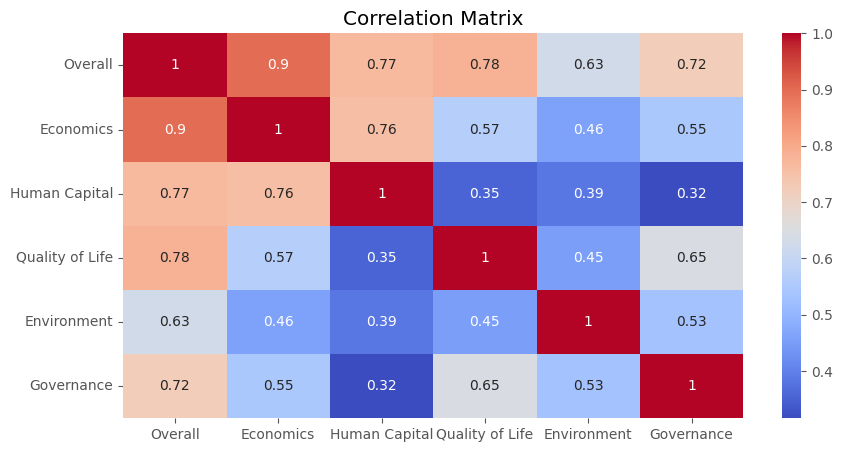

In [10]:
matrix=df.select_dtypes([int]).corr()

plt.figure(figsize=(10,5))
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

plt.show()

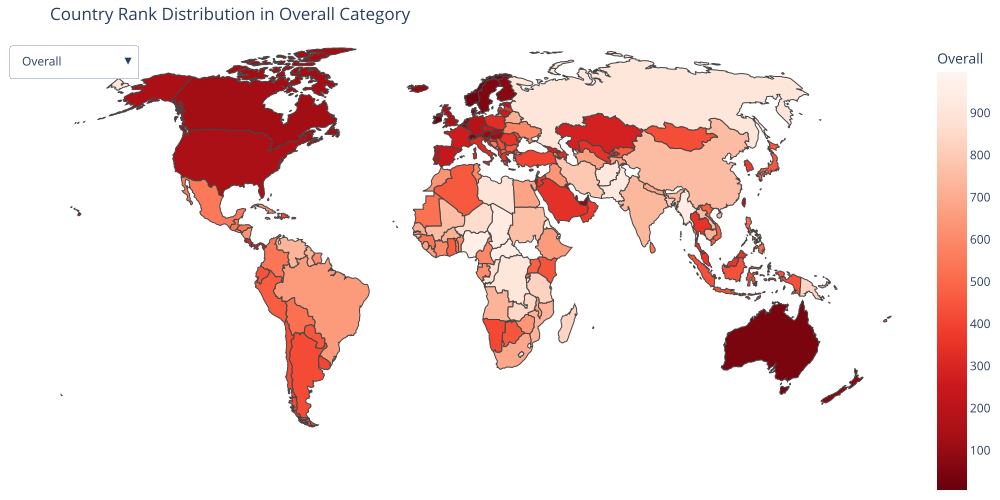

In [22]:

grouped = df.groupby('Country')[['Overall', 'Economics', 'Human Capital', 'Quality of Life', 'Environment', 'Governance']].median()

cols = ['Overall', 'Economics', 'Human Capital', 'Quality of Life', 'Environment', 'Governance']

fig = go.Figure()

for i, col in enumerate(cols):
    fig.add_trace(go.Choropleth(
        locations=grouped.index,
        locationmode='country names',
        z=grouped[col],
        colorscale='Reds_r',
        colorbar_title=col,
        visible=(i == 0)
    ))

buttons = []
for i, col in enumerate(cols):
    vis = [False] * len(cols)
    vis[i] = True
    buttons.append(dict(
        label=col,
        method='update',
        args=[{'visible': vis},
              {'title.text': f'Country Rank Distribution by {col}'}]   # title changes with the dropdown
    ))

fig.update_layout(
    title_text=f'Country Rank Distribution in {cols[0]} Category',
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        x=0.01, y=0.99,
        xanchor='left', yanchor='top'
    )],
    margin=dict(l=0, r=0, t=40, b=0),
    width=1000,
    height=500
)

fig.update_geos(projection_type='natural earth', visible=False)

fig.show('svg')